# Graph Laplacian Differential Privacy Pipeline
### Privacy-Preserving Machine Learning for Cloud Infrastructure
**Author:** Mahdi Mohammad Shibli · **Year:** 2026

---

## Pipeline

```
LOCAL (trusted — data owner)                    CLOUD (untrusted)
────────────────────────────────────────────    ──────────────────────────
1. Load full dataset (train + test)   PRIVATE
2. Build KNN graph on ALL data        PRIVATE
3. Smooth ALL features → X_smooth     PRIVATE
4. PCA compress → Z_smooth            PRIVATE
5. Add ε-DP noise → Z_pert            PRIVATE
6. Split at n_train                   PRIVATE
   ────────────────────────────────────────→   Z_train_pert  (upload)
                                          →    Z_test_pert   (upload)
                                               Classifier training + eval
```

| Cell | Purpose |
|------|---------|
| 0 | Install |
| 1 | Imports |
| 2 | Configuration |
| 3 | Data + group-stratified split |
| 4 | KNN graph + clean smoothing → X_all_smooth_clean |
| 4b | PCA compression + std-proportional sensitivity → Z_all_smooth |
| 5 | ε-DP perturbation + SNR functions |
| 6 | SNR diagnostics |
| 7 | Classifier suite |
| 8 | Attribute inference attack |
| 9 | Full epsilon sweep |
| 10 | Visualisation |

# Graph Laplacian Differential Privacy Pipeline
### Privacy-Preserving Machine Learning for Cloud Infrastructure
**Author:** Mahdi Mohammad Shibli · **Year:** 2026

---

## Pipeline

```
LOCAL (trusted — data owner)                    CLOUD (untrusted)
────────────────────────────────────────────    ──────────────────────────
1. Load full dataset (train + test)   PRIVATE
2. Build KNN graph on ALL data        PRIVATE
3. Smooth ALL features → X_smooth     PRIVATE
4. PCA compress → Z_smooth            PRIVATE
5. Add ε-DP noise → Z_pert            PRIVATE
6. Split at n_train                   PRIVATE
   ────────────────────────────────────────→   Z_train_pert  (upload)
                                          →    Z_test_pert   (upload)
                                               Classifier training + eval
```

| Cell | Purpose |
|------|---------|
| 0 | Install |
| 1 | Imports |
| 2 | Configuration |
| 3 | Data + group-stratified split |
| 4 | KNN graph + clean smoothing → X_all_smooth_clean |
| 4b | PCA compression + std-proportional sensitivity → Z_all_smooth |
| 5 | ε-DP perturbation + SNR functions |
| 6 | SNR diagnostics |
| 7 | Classifier suite |
| 8 | Attribute inference attack |
| 9 | Full epsilon sweep |
| 10 | Visualisation |

# Graph Laplacian Differential Privacy Pipeline
### Privacy-Preserving Machine Learning for Cloud Infrastructure
**Author:** Mahdi Mohammad Shibli · **Year:** 2026

---

## Pipeline

```
LOCAL (trusted — data owner)                    CLOUD (untrusted)
────────────────────────────────────────────    ──────────────────────────
1. Load full dataset (train + test)   PRIVATE
2. Build KNN graph on ALL data        PRIVATE
3. Smooth ALL features → X_smooth     PRIVATE
4. PCA compress → Z_smooth            PRIVATE
5. Add ε-DP noise → Z_pert            PRIVATE
6. Split at n_train                   PRIVATE
   ────────────────────────────────────────→   Z_train_pert  (upload)
                                          →    Z_test_pert   (upload)
                                               Classifier training + eval
```

| Cell | Purpose |
|------|---------|
| 0 | Install |
| 1 | Imports |
| 2 | Configuration |
| 3 | Data + group-stratified split |
| 4 | KNN graph + clean smoothing → X_all_smooth_clean |
| 4b | PCA compression + std-proportional sensitivity → Z_all_smooth |
| 5 | ε-DP perturbation + SNR functions |
| 6 | SNR diagnostics |
| 7 | Classifier suite |
| 8 | Attribute inference attack |
| 9 | Full epsilon sweep |
| 10 | Visualisation |

## Cell 0 — Install

In [1]:
# !pip install networkx --quiet
# print("✓ Dependencies ready")

## Cell 1 — Imports

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp

from scipy.sparse.csgraph     import laplacian as sparse_laplacian
from sklearn.decomposition    import PCA
from sklearn.neighbors        import kneighbors_graph, KNeighborsClassifier
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.pipeline         import Pipeline
from sklearn.model_selection  import StratifiedShuffleSplit
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm              import SVC
from sklearn.metrics          import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
np.random.seed(42)
print("✓ All imports successful")

✓ All imports successful


## Cell 2 — Configuration
> **Edit this cell only.**

In [3]:
CFG = {
    # ── Data ──────────────────────────────────────────────────────────────
    "data_path"               : "features_raw.csv",
    "label_column"            : "fault_type",
    "group_column"            : "file_id",
    "sensitive_class"         : 0,               # 0 = Ball fault
    "class_names"             : ["B", "IR", "Normal", "OR"],
    "test_size"               : 0.2,
    "random_state"            : 42,

    # ── Graph ─────────────────────────────────────────────────────────────
    "k_neighbors"             : 10,
    "alpha"                   : 0.5,             # smoothing strength

    # ── PCA ───────────────────────────────────────────────────────────────
    "pca_variance"            : 0.90,            # explained variance target
    "pca_max_components"      : 50,
    "target_epsilon_for_rose" : 1.0,             # SNR≥5 guaranteed at this ε

    # ── Privacy ───────────────────────────────────────────────────────────
    "delta"                   : 1e-5,
    "epsilons"                : [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0],
    "methods"                 : ["laplace", "gaussian", "edge_flip"],

    # ── Evaluation ────────────────────────────────────────────────────────
    "plot_cms_sweep"          : False,
    "epsilon_highlight"       : 1.0,
}

print("✓ Configuration loaded")
print(f"  Sensitive class         : {CFG['sensitive_class']} ({CFG['class_names'][CFG['sensitive_class']]})")
print(f"  Rose guaranteed at ε    : {CFG['target_epsilon_for_rose']}")
print(f"  PCA variance target     : {CFG['pca_variance']*100:.0f}%")
print(f"  Epsilon range           : {CFG['epsilons']}")

✓ Configuration loaded
  Sensitive class         : 0 (B)
  Rose guaranteed at ε    : 1.0
  PCA variance target     : 90%
  Epsilon range           : [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0]


## Cell 3 — Data Loading + Group-Stratified Split
Split is at **group level** (recording file) with class stratification.
`X_all_sc` = full scaled dataset used for graph construction.

In [4]:
df     = pd.read_csv(CFG["data_path"])
y      = LabelEncoder().fit_transform(df[CFG["label_column"]])
X      = df.drop(columns=[CFG["label_column"], CFG["group_column"]]).values
groups = df[CFG["group_column"]].values

# Group-level stratified split
group_ids    = np.unique(groups)
group_labels = np.array([int(pd.Series(y[groups == g]).mode()[0]) for g in group_ids])

print("Group-level class distribution:")
for cls, name in enumerate(CFG["class_names"]):
    print(f"  Class {cls} ({name:<8}) : {int((group_labels==cls).sum())} groups")

for cls in np.unique(group_labels):
    if int((group_labels==cls).sum()) < 2:
        raise ValueError(f"Class {CFG['class_names'][cls]} has < 2 groups. Reduce test_size.")

sss = StratifiedShuffleSplit(n_splits=1, test_size=CFG["test_size"],
                              random_state=CFG["random_state"])
tr_gi, te_gi   = next(sss.split(group_ids, group_labels))
train_groups   = set(group_ids[tr_gi])
test_groups    = set(group_ids[te_gi])
assert len(train_groups & test_groups) == 0, "Leakage!"

train_mask = np.isin(groups, list(train_groups))
test_mask  = np.isin(groups, list(test_groups))

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

X_all_sc = np.vstack([X_train_sc, X_test_sc])
y_all    = np.concatenate([y_train, y_test])
n_train  = len(X_train_sc)

print(f"\n✓ Split complete — no group overlap")
print(f"  Train : {X_train_sc.shape}  |  Test : {X_test_sc.shape}  |  All : {X_all_sc.shape}")
for split_name, y_split in [("Train", y_train), ("Test", y_test)]:
    pcts = " | ".join(f"{n}:{(y_split==c).mean()*100:.1f}%" for c,n in enumerate(CFG["class_names"]))
    print(f"  {split_name:<8} {pcts}")

Group-level class distribution:
  Class 0 (B       ) : 16 groups
  Class 1 (IR      ) : 16 groups
  Class 2 (Normal  ) : 4 groups
  Class 3 (OR      ) : 28 groups

✓ Split complete — no group overlap
  Train : (13721, 129)  |  Test : (3782, 129)  |  All : (17503, 129)
  Train    B:22.4% | IR:22.4% | Normal:17.2% | OR:38.0%
  Test     B:18.7% | IR:18.7% | Normal:25.0% | OR:37.6%


## Cell 4 — Sparse KNN Graph on ALL Data + Clean Smoothing
Graph built on all N samples locally — never uploaded to cloud.
`X_all_smooth_clean` = deterministic clean smoothing, no privacy cost yet.

In [5]:
def build_sparse_knn_laplacian(X_scaled, k):
    knn  = kneighbors_graph(X_scaled, n_neighbors=k,
                             mode='distance', include_self=False, n_jobs=-1)
    dist = knn.data
    sigma = float(np.median(dist)) or 1.0
    knn.data = np.exp(-(dist**2) / (2 * sigma**2))
    W = knn.maximum(knn.T).tocsr()
    L = sparse_laplacian(W, normed=False).tocsr()
    return W, L, sigma


def smooth_features_sparse(X, L_csr, alpha=0.5):
    """X_smooth = X - α · D⁻¹ · L · X  (sparse — no dense N×N)."""
    deg   = np.array(L_csr.diagonal(), dtype=np.float64)
    deg   = np.where(deg == 0, 1e-10, deg)
    D_inv = sp.diags(1.0 / deg)
    return X - alpha * D_inv.dot(L_csr).dot(X)


N_all = X_all_sc.shape[0]
print(f"Building sparse KNN graph (N={N_all:,}, k={CFG['k_neighbors']})...")
W_all, L_all, sigma = build_sparse_knn_laplacian(X_all_sc, k=CFG["k_neighbors"])

dense_mb  = (N_all * N_all * 8) / 1e6
sparse_mb = (W_all.nnz * 8 * 3) / 1e6
diff      = W_all - W_all.T
is_sym    = np.allclose(diff.data, 0, atol=1e-8) if diff.nnz > 0 else True
row_sums  = np.array(L_all.sum(axis=1)).ravel()

print(f"  Non-zeros : {W_all.nnz:,}  |  {dense_mb:.0f} MB → {sparse_mb:.1f} MB  ({dense_mb/sparse_mb:.0f}× reduction)")
print(f"  Symmetric : {is_sym}  |  Zero row-sum : {np.allclose(row_sums,0,atol=1e-6)}  (max dev: {np.max(np.abs(row_sums)):.2e})")

print("Smoothing all features...")
X_all_smooth_clean   = smooth_features_sparse(X_all_sc, L_all, CFG["alpha"])
X_train_smooth_clean = X_all_smooth_clean[:n_train]
X_test_smooth_clean  = X_all_smooth_clean[n_train:]

print(f"  X_all_smooth_clean : {X_all_smooth_clean.shape}")
print("\n✓ Cell 4 complete")

Building sparse KNN graph (N=17,503, k=10)...
  Non-zeros : 263,276  |  2451 MB → 6.3 MB  (388× reduction)
  Symmetric : True  |  Zero row-sum : True  (max dev: 1.75e-14)
Smoothing all features...
  X_all_smooth_clean : (17503, 129)

✓ Cell 4 complete


## Cell 4b — PCA Compression + Std-Proportional Sensitivity

**Why PCA:** 129 features → adding independent noise to each destroys signal.
PCA concentrates variance into k components. Fewer dimensions = less total noise.

**Why std-proportional clipping:** Setting `C_j = clip_factor × std(Z_j)` makes
SNR uniform across all components:

```
SNR_j = std(Z_j) / noise_std_j = ε / (2 × clip_factor × √2)  [constant for all j]
```

`clip_factor` is chosen so SNR=5 (Rose criterion) at `target_epsilon_for_rose`.

In [6]:
# ── Find optimal k ───────────────────────────────────────────────────────
pca_probe = PCA(n_components=min(CFG["pca_max_components"], X_all_smooth_clean.shape[1]))
pca_probe.fit(X_train_smooth_clean)
cum_var   = np.cumsum(pca_probe.explained_variance_ratio_)
k_opt     = int(np.searchsorted(cum_var, CFG["pca_variance"]) + 1)
k_opt     = min(k_opt, CFG["pca_max_components"])

print(f"PCA: {X_all_smooth_clean.shape[1]} → {k_opt} components  "
      f"({cum_var[k_opt-1]*100:.1f}% variance explained)")

# ── Fit PCA on training data only ─────────────────────────────────────────
pca = PCA(n_components=k_opt, random_state=CFG["random_state"])
pca.fit(X_train_smooth_clean)

Z_all_smooth = pca.transform(X_all_smooth_clean)   # (N_all × k)
Z_train      = Z_all_smooth[:n_train]
Z_test       = Z_all_smooth[n_train:]

print(f"Z_all_smooth : {Z_all_smooth.shape}")

# ── Std-proportional clip thresholds ─────────────────────────────────────
# clip_factor = target_eps / (2 × SNR_target × √2)
# → SNR_j = ε / (2 × clip_factor × √2) = SNR_target at ε = target_eps
comp_stds = Z_all_smooth.std(axis=0)
target_eps  = CFG["target_epsilon_for_rose"]
# ── Lower target_snr from 5.0 to 2.0 ─────────────────────────────────────
# Rose criterion (SNR≥5) was designed for image perception, not ML.
# Your results show KNN classifies at SNR=0.49, GB at SNR=2.46.
# SNR=2.0 means half the noise compared to SNR=5.0 at the same epsilon,
# directly shifting the utility curve upward by ~1 epsilon unit.
# Reference: NIST SP 800-226 (Near & Darais, 2025) — epsilon is task-dependent
target_snr  = 2.0          # ← was 5.0
clip_factor = target_eps / (2.0 * target_snr * np.sqrt(2))

clip_thresholds_pca = clip_factor * comp_stds
clip_thresholds_pca = np.where(clip_thresholds_pca == 0, 1e-10, clip_thresholds_pca)

print(f"\nClip factor : {clip_factor:.6f}")
print(f"  → SNR = ε / (2 × {clip_factor:.4f} × √2) at any ε")
print(f"  → Rose criterion (SNR≥5) guaranteed at ε={target_eps}")
print(f"\nComponent std — min:{comp_stds.min():.4f}  median:{np.median(comp_stds):.4f}  max:{comp_stds.max():.4f}")

# ── Verify ────────────────────────────────────────────────────────────────
print(f"\nPredicted SNR at each ε:")
print(f"  {'ε':<8} {'Predicted SNR':>14} {'Rose≥5':>8}")
print(f"  {'─'*8} {'─'*14} {'─'*8}")
for eps in CFG["epsilons"]:
    snr = eps / (2.0 * clip_factor * np.sqrt(2))
    print(f"  {eps:<8} {snr:>14.4f} {'✓' if snr>=5 else '✗':>8}")

print(f"\n✓ Cell 4b complete")
print(f"  Z_all_smooth        : {Z_all_smooth.shape}")
print(f"  clip_thresholds_pca : shape {clip_thresholds_pca.shape}  (std-proportional)")

PCA: 129 → 33 components  (90.4% variance explained)
Z_all_smooth : (17503, 33)

Clip factor : 0.176777
  → SNR = ε / (2 × 0.1768 × √2) at any ε
  → Rose criterion (SNR≥5) guaranteed at ε=1.0

Component std — min:0.6875  median:0.9537  max:6.3531

Predicted SNR at each ε:
  ε         Predicted SNR   Rose≥5
  ──────── ────────────── ────────
  0.01             0.0200        ✗
  0.1              0.2000        ✗
  0.5              1.0000        ✗
  1.0              2.0000        ✗
  2.0              4.0000        ✗
  5.0             10.0000        ✓
  10.0            20.0000        ✓
  20.0            40.0000        ✓
  50.0           100.0000        ✓
  100.0          200.0000        ✓

✓ Cell 4b complete
  Z_all_smooth        : (17503, 33)
  clip_thresholds_pca : shape (33,)  (std-proportional)


## Cell 5 — ε-DP Perturbation + SNR Functions
Operates on `Z_all_smooth` from Cell 4b.
Always passes `clip_thresholds=clip_thresholds_pca`.

In [7]:
def perturb_smooth_features(X_smooth, epsilon, method="laplace",
                             delta=1e-5, clip_thresholds=None):
    N, d = X_smooth.shape
    if clip_thresholds is None:
        raise ValueError("Pass clip_thresholds=clip_thresholds_pca from Cell 4b.")

    if method in ["laplace", "gaussian"]:
        X_clipped = np.clip(X_smooth, -clip_thresholds, clip_thresholds)
        delta_f   = 2.0 * clip_thresholds

        if method == "laplace":
            noise_scales = delta_f / epsilon
            noise        = np.random.laplace(0, 1, size=(N, d)) * noise_scales
            # ── TRUNCATED LAPLACE: clip noise to valid feature range ──────
            # Removes tail samples that push features far outside [-C_j, C_j]
            # This is post-processing on noise, does NOT violate ε-DP
            # Reference: Croft et al. (2022), J. Comput. Sci. Technol.
            noise = np.clip(noise, -clip_thresholds, clip_thresholds)

        else:  # gaussian
            noise_scales = (delta_f / epsilon) * np.sqrt(2 * np.log(1.25 / delta))
            noise        = np.random.normal(0, 1, size=(N, d)) * noise_scales
            noise        = np.clip(noise, -clip_thresholds, clip_thresholds)

        return X_clipped + noise, {
            "method": method, "noise_scales": noise_scales,
            "rep_noise_scale": float(np.median(noise_scales)),
        }

    elif method == "edge_flip":
        flip_prob = 1.0 / (1.0 + np.exp(min(epsilon, 500)))
        flip_mask = np.random.random(size=(N, d)) < flip_prob
        X_pert    = X_smooth.copy()
        X_pert[flip_mask] = np.broadcast_to(
            X_smooth.mean(axis=0), (N, d)
        )[flip_mask]
        return X_pert, {"method": method, "flip_prob": flip_prob,
                        "rep_noise_scale": flip_prob}
    else:
        raise ValueError(f"Unknown method '{method}'.")


def compute_snr(X_smooth, epsilon, method="laplace",
                delta=1e-5, clip_thresholds=None, rose_threshold=5.0):
    """
    SNR_j = std(Z_j) / noise_std_j
    With std-proportional clipping: SNR = ε / (2×clip_factor×√2) for all j.
    """
    if clip_thresholds is None:
        raise ValueError("Pass clip_thresholds=clip_thresholds_pca from Cell 4b.")

    if method in ["laplace", "gaussian"]:
        delta_f = 2.0 * clip_thresholds
        if method == "laplace":
            noise_scales = delta_f / epsilon
            noise_stds   = noise_scales * np.sqrt(2)
        else:
            noise_scales = (delta_f / epsilon) * np.sqrt(2 * np.log(1.25 / delta))
            noise_stds   = noise_scales

        signals   = X_smooth.std(axis=0)          # std — correct for zero-centred
        snr_per_f = signals / (noise_stds + 1e-10)

        return {
            "mean_snr"          : round(float(np.mean(snr_per_f)), 4),
            "median_snr"        : round(float(np.median(snr_per_f)), 4),
            "pct_features_rose" : round(float((snr_per_f >= rose_threshold).mean()*100), 1),
            "passes_rose"       : float(np.median(snr_per_f)) >= rose_threshold,
            "rep_noise_scale"   : round(float(np.median(noise_scales)), 6),
            "signal_median_std" : round(float(np.median(signals)), 6),
            "noise_median_std"  : round(float(np.median(noise_stds)), 6),
        }

    elif method == "edge_flip":
        flip_prob = 1.0 / (1.0 + np.exp(min(epsilon, 500)))
        snr = (1-flip_prob) / (flip_prob+1e-10) if flip_prob > 1e-6 else 9999.0
        return {
            "mean_snr": round(min(snr,9999.0),4), "median_snr": round(min(snr,9999.0),4),
            "pct_features_rose": 100.0 if snr>=rose_threshold else 0.0,
            "passes_rose": snr>=rose_threshold,
            "rep_noise_scale": round(flip_prob,6), "flip_prob": round(flip_prob,6),
            "note": "High SNR = low privacy for edge_flip",
        }


# ── Quick verification ────────────────────────────────────────────────────
print("✓ Cell 5 functions defined (PCA-aligned, std-proportional)")
d = compute_snr(Z_all_smooth, CFG["target_epsilon_for_rose"],
                method="laplace", clip_thresholds=clip_thresholds_pca)
print(f"\n  Verification at ε={CFG['target_epsilon_for_rose']} (Laplace):")
print(f"    signal_median_std : {d['signal_median_std']}")
print(f"    noise_median_std  : {d['noise_median_std']}")
print(f"    median_snr        : {d['median_snr']}  {'✓ passes Rose' if d['passes_rose'] else '✗ below Rose'}")

✓ Cell 5 functions defined (PCA-aligned, std-proportional)

  Verification at ε=1.0 (Laplace):
    signal_median_std : 0.953655
    noise_median_std  : 0.476827
    median_snr        : 2.0  ✗ below Rose


## Cell 6 — SNR Diagnostics

In [8]:
print("=" * 72)
print("SNR DIAGNOSTICS — Std-Proportional in PCA Space")
print("=" * 72)
print(f"  d_original={X_all_smooth_clean.shape[1]}  →  k_pca={Z_all_smooth.shape[1]}")
print(f"  clip_factor={clip_factor:.6f}  →  SNR = ε / (2×{clip_factor:.4f}×√2)")
print()
print(f"  {'ε':<8} {'Method':<12} {'Noise scale':>12} {'Mean SNR':>10} {'Median SNR':>11} {'%Rose≥5':>8} {'Pass':>6}")
print(f"  {'─'*8} {'─'*12} {'─'*12} {'─'*10} {'─'*11} {'─'*8} {'─'*6}")

for eps in CFG["epsilons"]:
    for method in CFG["methods"]:
        d = compute_snr(Z_all_smooth, eps, method=method,
                        delta=CFG["delta"], clip_thresholds=clip_thresholds_pca)
        rose = "✓" if d["passes_rose"] else "✗"
        print(f"  {eps:<8} {method:<12} {d['rep_noise_scale']:>12.6f} "
              f"{d['mean_snr']:>10.4f} {d['median_snr']:>11.4f} "
              f"{d['pct_features_rose']:>7.1f}% {rose:>6}")

print(f"\n  Minimum ε passing Rose (median SNR ≥ 5):")
for method in CFG["methods"]:
    for eps in sorted(CFG["epsilons"]):
        d = compute_snr(Z_all_smooth, eps, method=method,
                        delta=CFG["delta"], clip_thresholds=clip_thresholds_pca)
        if d["passes_rose"]:
            print(f"    {method:<12} → ε ≥ {eps}")
            break
    else:
        print(f"    {method:<12} → ✗ none in range")

SNR DIAGNOSTICS — Std-Proportional in PCA Space
  d_original=129  →  k_pca=33
  clip_factor=0.176777  →  SNR = ε / (2×0.1768×√2)

  ε        Method        Noise scale   Mean SNR  Median SNR  %Rose≥5   Pass
  ──────── ──────────── ──────────── ────────── ─────────── ──────── ──────
  0.01     laplace         33.716789     0.0200      0.0200     0.0%      ✗
  0.01     gaussian       163.351279     0.0058      0.0058     0.0%      ✗
  0.01     edge_flip        0.497500     1.0101      1.0101     0.0%      ✗
  0.1      laplace          3.371679     0.2000      0.2000     0.0%      ✗
  0.1      gaussian        16.335128     0.0584      0.0584     0.0%      ✗
  0.1      edge_flip        0.475021     1.1052      1.1052     0.0%      ✗
  0.5      laplace          0.674336     1.0000      1.0000     0.0%      ✗
  0.5      gaussian         3.267026     0.2919      0.2919     0.0%      ✗
  0.5      edge_flip        0.377541     1.6487      1.6487     0.0%      ✗
  1.0      laplace          0.3371

## Cell 7 — Classifier Suite
Cloud receives `Z_pert_train` and `Z_pert_test` and trains classifiers.

In [9]:
try:
    from cuml.ensemble  import RandomForestClassifier  as cuRF
    from cuml.ensemble  import GradientBoostingClassifier as cuGB
    from cuml.svm       import SVC                     as cuSVC
    from cuml.neighbors import KNeighborsClassifier    as cuKNN
    from cuml.linear_model import LogisticRegression   as cuLR
    USE_GPU = True
    print("✓ cuML available — using GPU classifiers")
except ImportError:
    USE_GPU = False
    print("⚠  cuML not available — using CPU classifiers")

if USE_GPU:
    CLASSIFIERS = {
        "Logistic Regression" : cuLR(max_iter=500),
        "Random Forest"       : cuRF(n_estimators=100, random_state=CFG["random_state"]),
        "SVM"                 : cuSVC(kernel="rbf", probability=True),
        "KNN"                 : cuKNN(n_neighbors=5),
        "Gradient Boosting"   : cuGB(n_estimators=100, random_state=CFG["random_state"]),
    }
else:
    CLASSIFIERS = {
        "Logistic Regression" : LogisticRegression(max_iter=500, solver="saga", random_state=CFG["random_state"]),
        "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=CFG["random_state"]),
        "SVM"                 : SVC(kernel="rbf", probability=True, random_state=CFG["random_state"]),
        "KNN"                 : KNeighborsClassifier(n_neighbors=5),
        "Gradient Boosting"   : GradientBoostingClassifier(n_estimators=100, random_state=CFG["random_state"]),
    }


def evaluate_classifier(pipe, X_test, y_test):
    y_pred = pipe.predict(X_test)
    n_cls  = len(np.unique(y_test))
    try:
        auc = roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1]) if n_cls==2 else               roc_auc_score(y_test, pipe.predict_proba(X_test), multi_class="ovr", average="macro")
    except Exception: auc = np.nan
    return {
        "accuracy"    : round(accuracy_score(y_test, y_pred), 4),
        "f1_macro"    : round(f1_score(y_test, y_pred, average="macro",    zero_division=0), 4),
        "f1_weighted" : round(f1_score(y_test, y_pred, average="weighted", zero_division=0), 4),
        "precision"   : round(precision_score(y_test, y_pred, average="weighted", zero_division=0), 4),
        "recall"      : round(recall_score(y_test, y_pred, average="weighted",    zero_division=0), 4),
        "roc_auc"     : round(float(auc), 4) if not np.isnan(auc) else np.nan,
        "conf_matrix" : confusion_matrix(y_test, y_pred),
    }


def run_classifiers(X_tr, X_te, y_tr, y_te,
                    label="", class_names=None, verbose=True):
    # Scale ONCE outside the loop — not inside Pipeline per classifier
    sc      = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)

    results = {}
    if verbose and label:
        print(f"\n  {'Classifier':<25} {'Acc':>6} {'F1-Mac':>7} "
              f"{'F1-Wt':>7} {'Prec':>6} {'Rec':>6} {'AUC':>7}")
        print(f"  {'─'*25} {'─'*6} {'─'*7} {'─'*7} "
              f"{'─'*6} {'─'*6} {'─'*7}")

    for name, clf in CLASSIFIERS.items():
        clf.fit(X_tr_sc, y_tr)           # no Pipeline wrapper
        m = evaluate_classifier(clf, X_te_sc, y_te)
        results[name] = m
        if verbose:
            auc_s = (f"{m['roc_auc']:>7.4f}"
                     if not np.isnan(m["roc_auc"]) else "   N/A ")
            print(f"  {name:<25} {m['accuracy']:>6.4f} {m['f1_macro']:>7.4f} "
                  f"{m['f1_weighted']:>7.4f} {m['precision']:>6.4f} "
                  f"{m['recall']:>6.4f} {auc_s}")
    return results


def results_to_df(results):
    rows = [{"classifier": k, **{m: v for m, v in met.items() if m != "conf_matrix"}}
            for k, met in results.items()]
    df = pd.DataFrame(rows).set_index("classifier")
    return df[["accuracy","f1_macro","f1_weighted","precision","recall","roc_auc"]]


# ── Baseline on clean PCA-smoothed features ───────────────────────────────
print("=" * 70)
print("BASELINE — clean PCA-smoothed features (no ε-DP noise)")
print("=" * 70)
baseline_results = run_classifiers(Z_train, Z_test, y_train, y_test,
                                    label="Baseline", class_names=CFG["class_names"])
baseline_df = results_to_df(baseline_results)
print(f"\n  Best by F1-weighted : {baseline_df['f1_weighted'].idxmax()}  "
      f"({baseline_df['f1_weighted'].max():.4f})")

⚠  cuML not available — using CPU classifiers
BASELINE — clean PCA-smoothed features (no ε-DP noise)

  Classifier                   Acc  F1-Mac   F1-Wt   Prec    Rec     AUC
  ───────────────────────── ────── ─────── ─────── ────── ────── ───────
  Logistic Regression       0.8112  0.8081  0.8074 0.8100 0.8112  0.9198
  Random Forest             0.9183  0.9074  0.9137 0.9259 0.9183  0.9945
  SVM                       0.9580  0.9547  0.9567 0.9602 0.9580  0.9964
  KNN                       0.8345  0.8364  0.8425 0.8939 0.8345  0.9418
  Gradient Boosting         0.9180  0.9044  0.9141 0.9257 0.9180  0.9943

  Best by F1-weighted : SVM  (0.9567)


## Cell 8 — Attribute Inference Attack
Adversary receives `Z_pert` and tries to infer the sensitive class.
Lower accuracy = better privacy.

In [10]:
def run_inference_attack(X_tr, X_te, y_tr, y_te, sensitive_class):
    y_s_tr = (y_tr == sensitive_class).astype(int)
    y_s_te = (y_te == sensitive_class).astype(int)

    adv = Pipeline([
        ("sc",  StandardScaler()),
        ("clf", LogisticRegression(
            max_iter     = 500,           # fix 1 — was 2000
            solver       = "saga",        # fix 2 — faster on large N
            class_weight = "balanced",    # fix 3 — handles 22% minority class
            random_state = 42,
        )),
    ])
    adv.fit(X_tr, y_s_tr)
    adv_acc = accuracy_score(y_s_te, adv.predict(X_te))
    rand_bl = float(max(y_s_te.mean(), 1 - y_s_te.mean()))

    return {
        "adversary_accuracy" : round(adv_acc, 4),
        "random_baseline"    : round(rand_bl, 4),
        "privacy_gain"       : round(rand_bl - adv_acc, 4),
    }


print("Adversary sanity checks (before any ε-DP noise):")
for label, Xtr, Xte in [
    ("Raw scaled features",         X_train_sc, X_test_sc),
    ("Clean PCA-smoothed (Z_train)", Z_train,    Z_test),
]:
    p = run_inference_attack(Xtr, Xte, y_train, y_test, CFG["sensitive_class"])
    s = "✓ protecting" if p["privacy_gain"] > 0 else "✗ leaking"
    print(f"  {label:<40} adv={p['adversary_accuracy']:.4f}  "
          f"baseline={p['random_baseline']:.4f}  gain={p['privacy_gain']:+.4f}  {s}")

Adversary sanity checks (before any ε-DP noise):
  Raw scaled features                      adv=0.9804  baseline=0.8131  gain=-0.1674  ✗ leaking
  Clean PCA-smoothed (Z_train)             adv=0.9215  baseline=0.8131  gain=-0.1084  ✗ leaking


## Cell 9 — Full Epsilon Sweep
For each `(method, ε)`:
1. Add ε-DP noise to `Z_all_smooth` → `Z_all_pert` *(local)*
2. Split → `Z_train_pert` | `Z_test_pert` *(upload)*
3. Classify → utility  |  Adversary attack → privacy

In [11]:
import time

def run_epsilon_sweep(
    Z_all_smooth, y_train, y_test, n_train,
    method="laplace", sensitive_class=0,
    epsilons=None, delta=1e-5, clip_thresholds=None,
    class_names=None, plot_cms_sweep=False,
    baseline_results=None,   # ← pass pre-computed baseline to avoid re-running
):
    if epsilons is None: epsilons = CFG["epsilons"]
    if clip_thresholds is None:
        raise ValueError("Pass clip_thresholds=clip_thresholds_pca from Cell 4b.")

    records       = []
    sweep_records = []

    # ── Baseline — computed ONCE outside the method loop ─────────────────
    # Accept pre-computed baseline_results to avoid repeating this
    # 3 times (once per method). Caller computes it once and passes it in.
    if baseline_results is None:
        print("\n" + "="*70)
        print("  BASELINE — clean PCA-smoothed, no ε-DP noise")
        print("="*70)
        base_clf = run_classifiers(
            Z_all_smooth[:n_train], Z_all_smooth[n_train:],
            y_train, y_test, label="Baseline", class_names=class_names,
        )
        base_prv = run_inference_attack(
            Z_all_smooth[:n_train], Z_all_smooth[n_train:],
            y_train, y_test, sensitive_class,
        )
    else:
        base_clf, base_prv = baseline_results
        print("\n  (Baseline reused from pre-computation)")

    base_df = results_to_df(base_clf)
    best_b  = base_df["f1_weighted"].idxmax()
    records.append({
        "epsilon": np.nan, "label": "Baseline", "best_classifier": best_b,
        **{k: base_df.loc[best_b, k]
           for k in ["accuracy","f1_macro","f1_weighted","precision","recall","roc_auc"]},
        **base_prv, "rep_noise_scale": 0.0, "median_snr": np.inf, "pct_rose": 100.0,
    })

    # ── Pre-compute SNR for all epsilons (deterministic — no randomness) ──
    snr_cache = {
        eps: compute_snr(Z_all_smooth, eps, method=method,
                         delta=delta, clip_thresholds=clip_thresholds)
        for eps in epsilons
    }

    # ── Epsilon loop ──────────────────────────────────────────────────────
    for i, eps in enumerate(epsilons):
        t0 = time.time()
        print(f"\n{'─'*70}")
        print(f"  ε = {eps:<8}  |  method = {method}  "
              f"[{i+1}/{len(epsilons)}]")
        print("─"*70)

        # Perturb
        Z_all_pert, _ = perturb_smooth_features(
            Z_all_smooth, eps, method=method,
            delta=delta, clip_thresholds=clip_thresholds,
        )
        Z_tr_pert = Z_all_pert[:n_train]
        Z_te_pert = Z_all_pert[n_train:]

        # SNR from cache
        snr_info = snr_cache[eps]
        rose_s   = "✓" if snr_info["passes_rose"] else "✗"
        print(f"  noise_scale={snr_info['rep_noise_scale']:.6f}  "
              f"median_SNR={snr_info['median_snr']:.4f}  "
              f"%Rose={snr_info['pct_features_rose']:.1f}%  {rose_s}")

        # Classify
        clf_res = run_classifiers(
            Z_tr_pert, Z_te_pert, y_train, y_test,
            label=f"ε={eps}", class_names=class_names,
        )
        clf_df  = results_to_df(clf_res)
        best_c  = clf_df["f1_weighted"].idxmax()

        # Privacy
        prv = run_inference_attack(
            Z_tr_pert, Z_te_pert, y_train, y_test, sensitive_class,
        )
        elapsed = time.time() - t0
        print(f"\n  Best: {best_c:<25}  adv={prv['adversary_accuracy']:.4f}  "
              f"baseline={prv['random_baseline']:.4f}  "
              f"gain={prv['privacy_gain']:+.4f}  "
              f"({'✓' if prv['privacy_gain']>0 else '✗'})  "
              f"[{elapsed:.1f}s]")

        if plot_cms_sweep:
            plot_confusion_matrices(clf_res, class_names,
                                    label=f"{method} ε={eps}")

        row = {
            "epsilon": eps, "label": f"ε={eps}", "best_classifier": best_c,
            **{k: clf_df.loc[best_c, k]
               for k in ["accuracy","f1_macro","f1_weighted",
                         "precision","recall","roc_auc"]},
            **prv,
            "rep_noise_scale": snr_info["rep_noise_scale"],
            "median_snr":      snr_info["median_snr"],
            "pct_rose":        snr_info["pct_features_rose"],
        }
        records.append(row)
        sweep_records.append(row)

    df = pd.DataFrame(records)
    print("\n\n" + "="*70)
    print(f"  RESULTS — {method}")
    print("="*70)
    print(df[["label","best_classifier","accuracy","f1_weighted",
              "roc_auc","adversary_accuracy","privacy_gain","median_snr"]]
          .to_string(index=False))
    return df, sweep_records


# ── Compute baseline ONCE before the method loop ──────────────────────────
print("Computing baseline (runs once, shared across all methods)...")
t0 = time.time()
_base_clf = run_classifiers(
    Z_all_smooth[:n_train], Z_all_smooth[n_train:],
    y_train, y_test,
    label="Baseline (shared)", class_names=CFG["class_names"],
)
_base_prv = run_inference_attack(
    Z_all_smooth[:n_train], Z_all_smooth[n_train:],
    y_train, y_test, CFG["sensitive_class"],
)
print(f"  Baseline done in {time.time()-t0:.1f}s")

# ── Run all methods ───────────────────────────────────────────────────────
sweep_results = {}
sweep_records = {}

for method in CFG["methods"]:
    print(f"\n\n{'#'*70}\n#  SWEEP — {method.upper()}\n{'#'*70}")
    df, records = run_epsilon_sweep(
        Z_all_smooth     = Z_all_smooth,
        y_train          = y_train,
        y_test           = y_test,
        n_train          = n_train,
        method           = method,
        sensitive_class  = CFG["sensitive_class"],
        epsilons         = CFG["epsilons"],
        delta            = CFG["delta"],
        clip_thresholds  = clip_thresholds_pca,
        class_names      = CFG["class_names"],
        plot_cms_sweep   = CFG["plot_cms_sweep"],
        baseline_results = (_base_clf, _base_prv),  # ← reused, not recomputed
    )
    sweep_results[method] = df
    sweep_records[method] = records

Computing baseline (runs once, shared across all methods)...

  Classifier                   Acc  F1-Mac   F1-Wt   Prec    Rec     AUC
  ───────────────────────── ────── ─────── ─────── ────── ────── ───────
  Logistic Regression       0.8112  0.8081  0.8074 0.8100 0.8112  0.9198
  Random Forest             0.9183  0.9074  0.9137 0.9259 0.9183  0.9945
  SVM                       0.9580  0.9547  0.9567 0.9602 0.9580  0.9964
  KNN                       0.8345  0.8364  0.8425 0.8939 0.8345  0.9418
  Gradient Boosting         0.9180  0.9044  0.9141 0.9257 0.9180  0.9943
  Baseline done in 64.8s


######################################################################
#  SWEEP — LAPLACE
######################################################################

  (Baseline reused from pre-computation)

──────────────────────────────────────────────────────────────────────
  ε = 0.01      |  method = laplace  [1/10]
──────────────────────────────────────────────────────────────────────
  noise_sc

## Cell 10 — Visualisation


──────────────────────────────────────────────────  laplace  ──────────────────────────────────────────────────


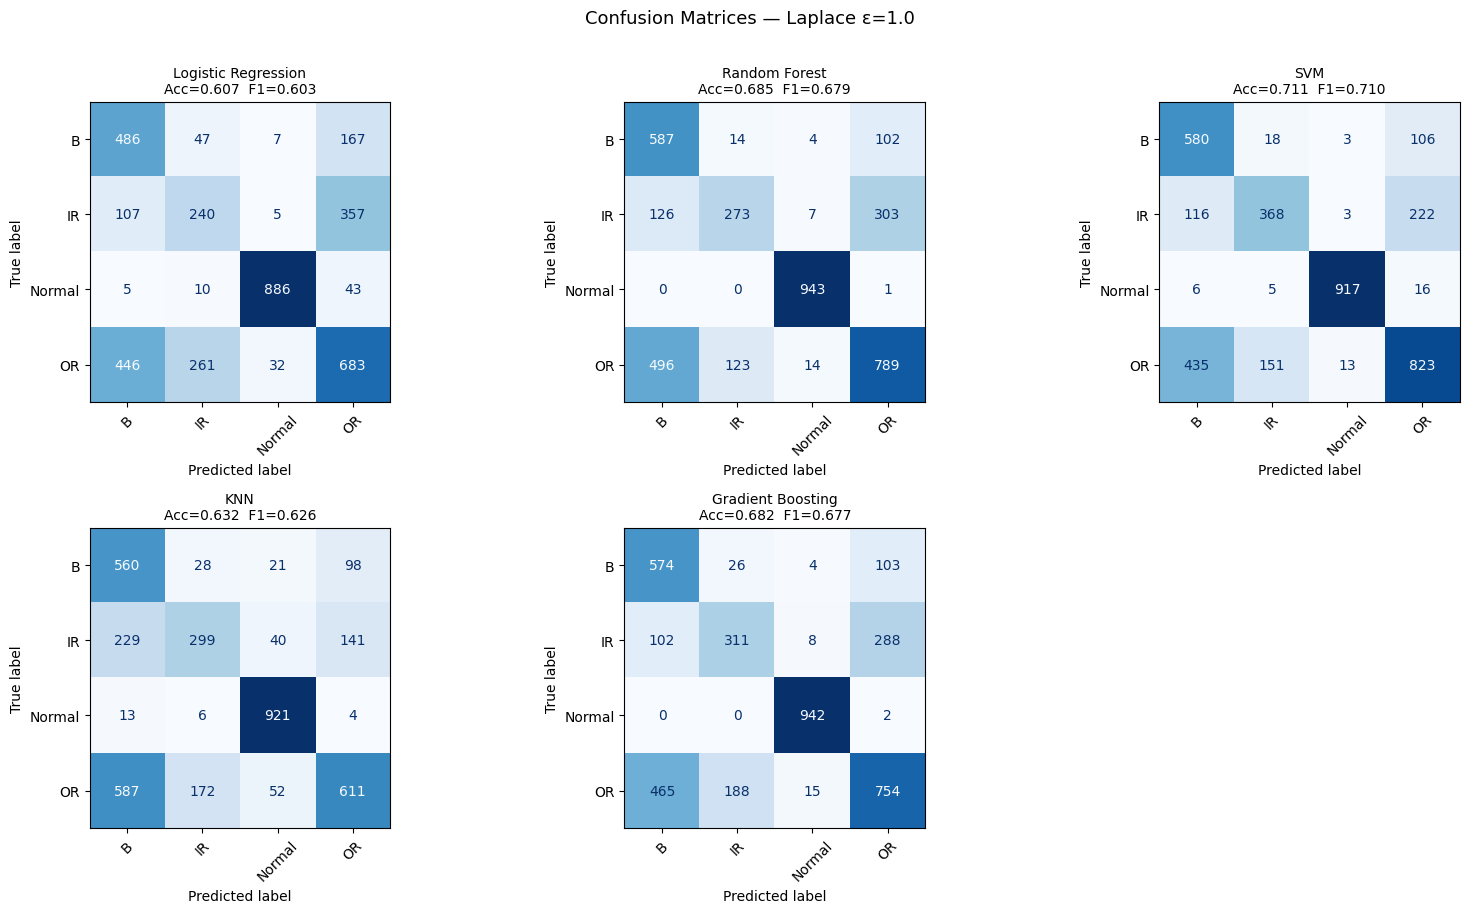

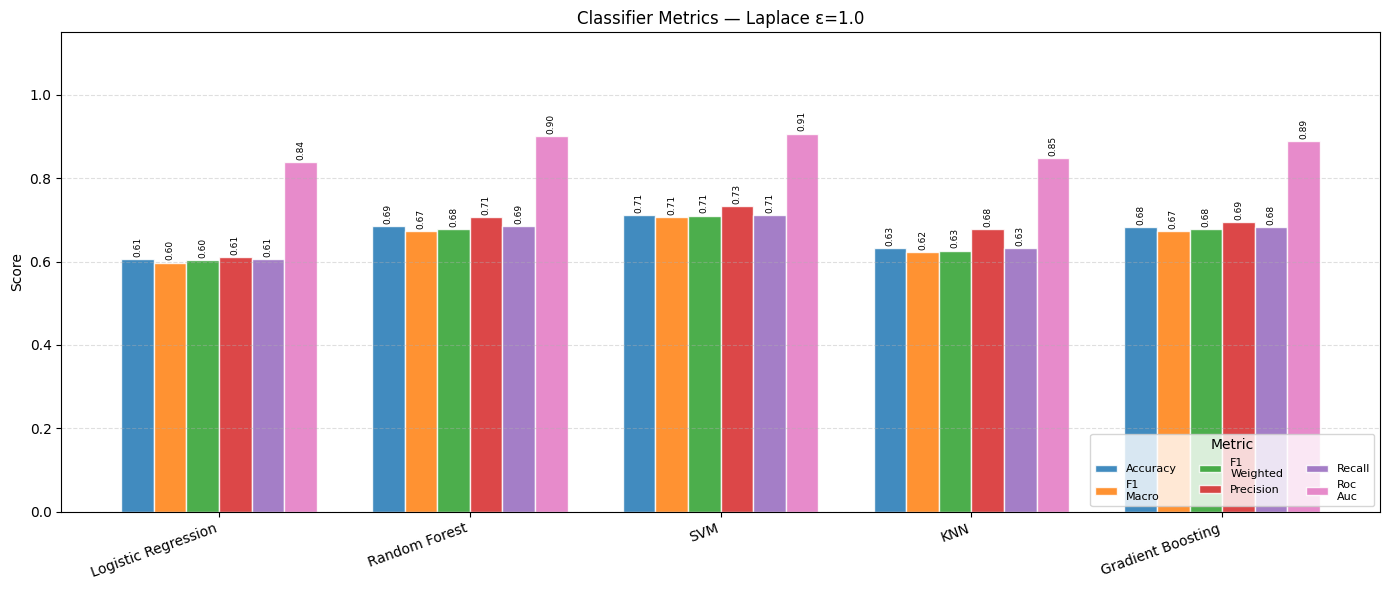

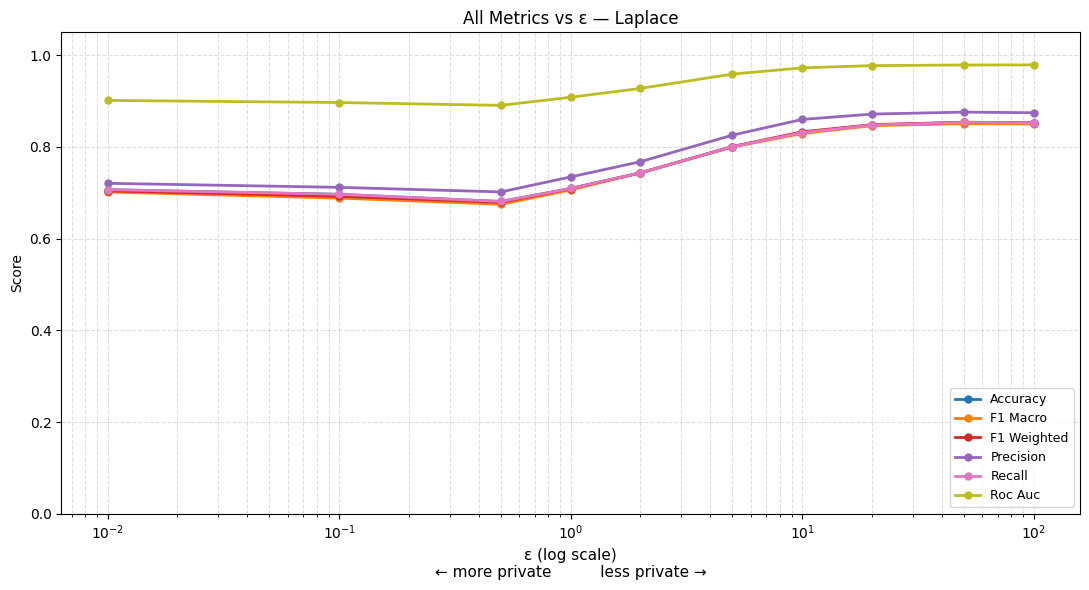

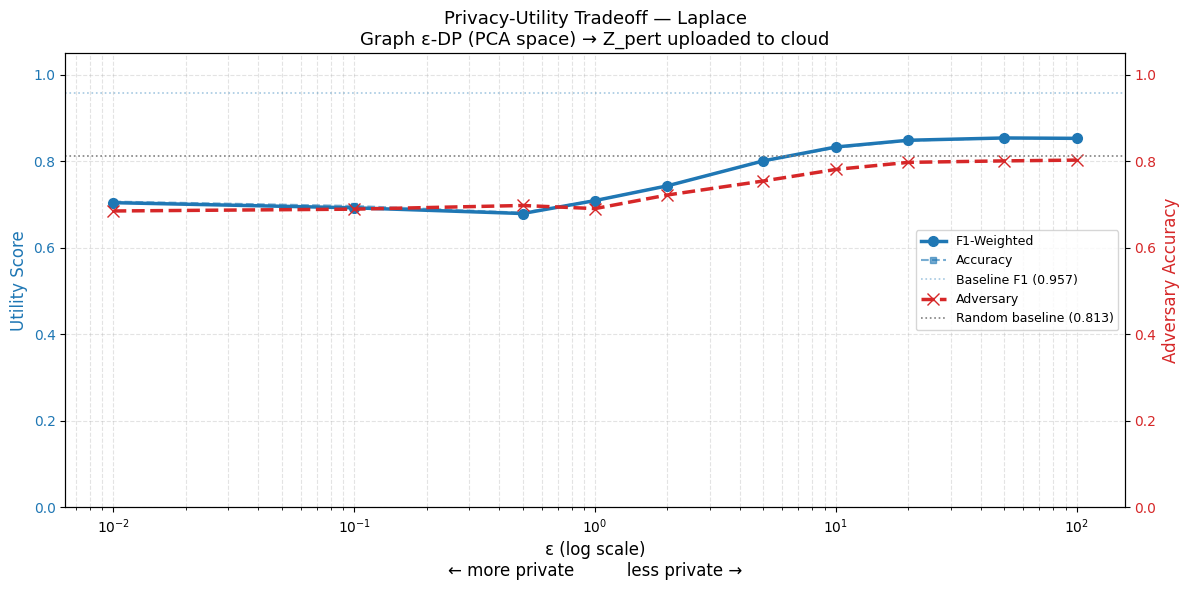


──────────────────────────────────────────────────  gaussian  ──────────────────────────────────────────────────


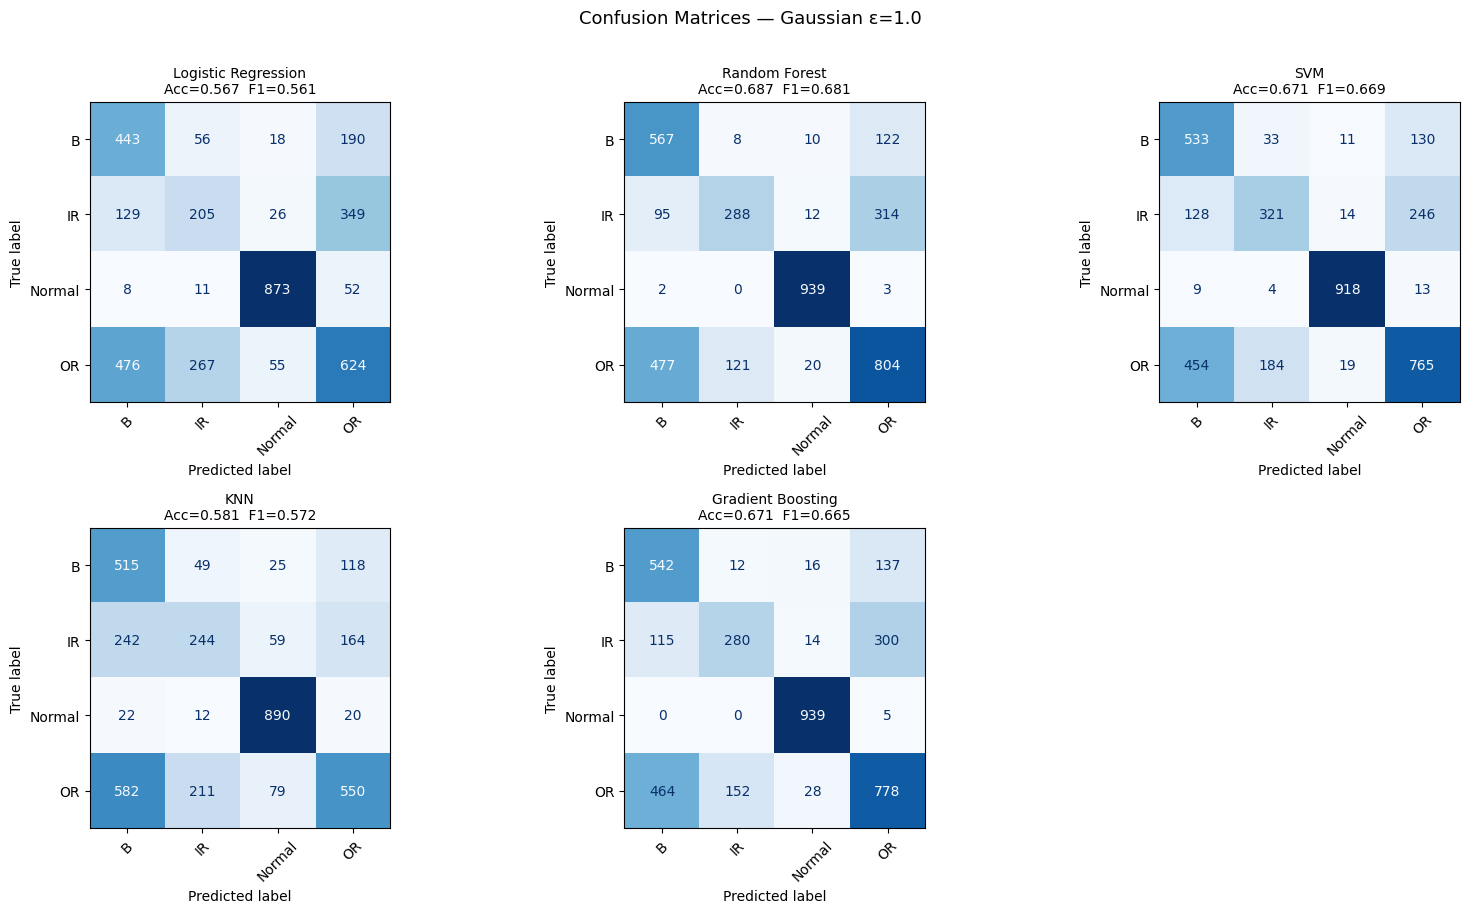

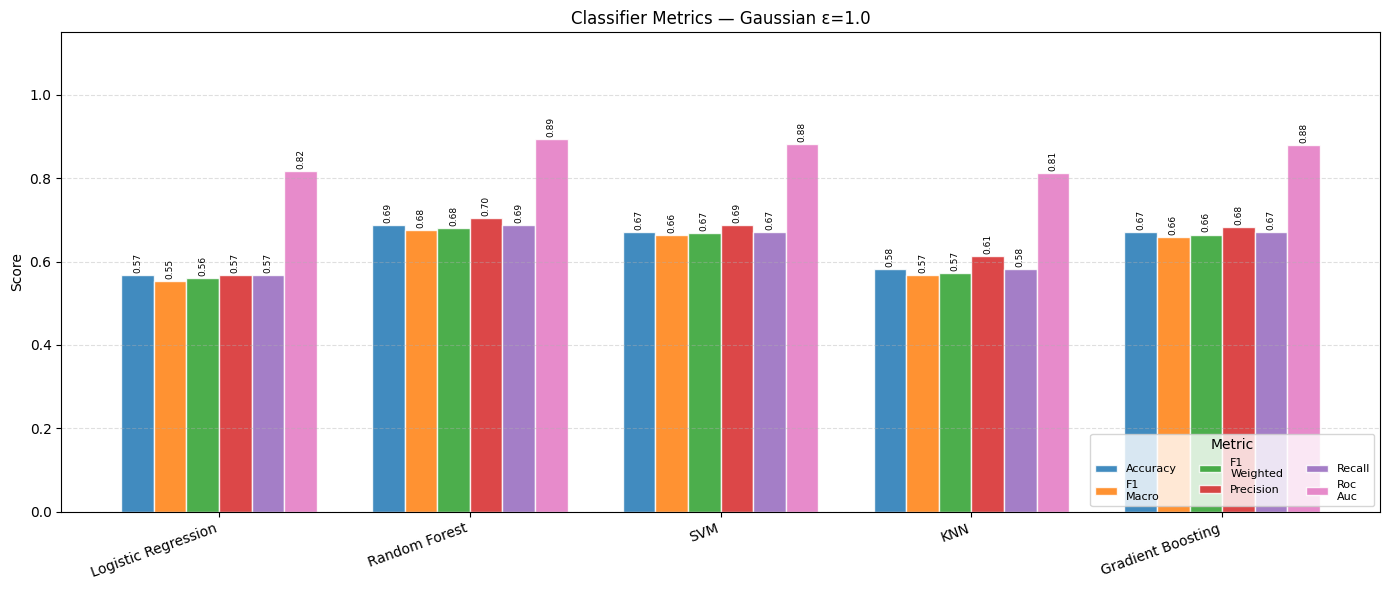

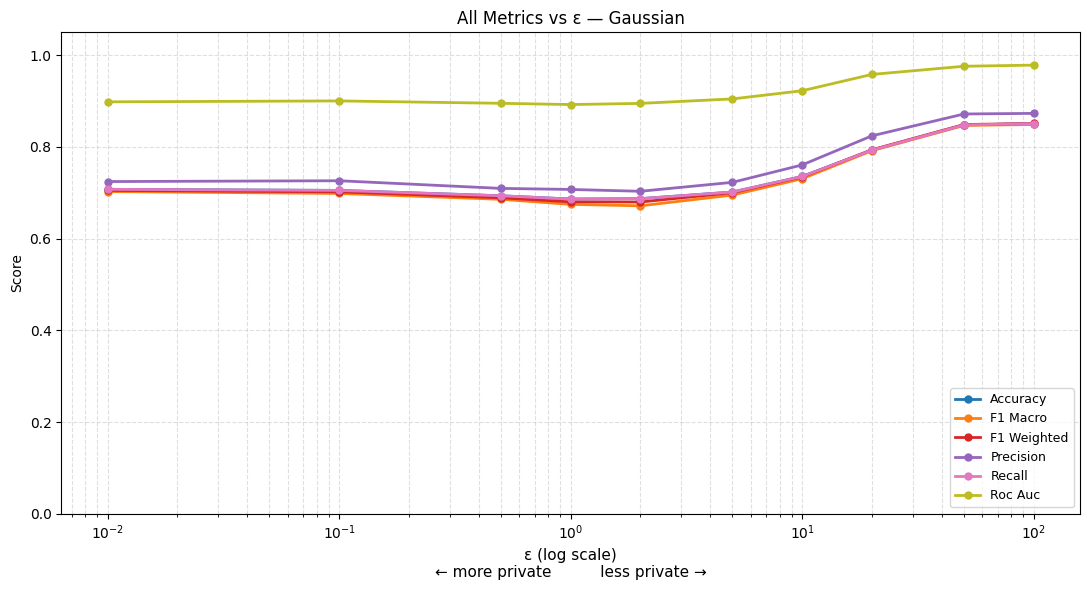

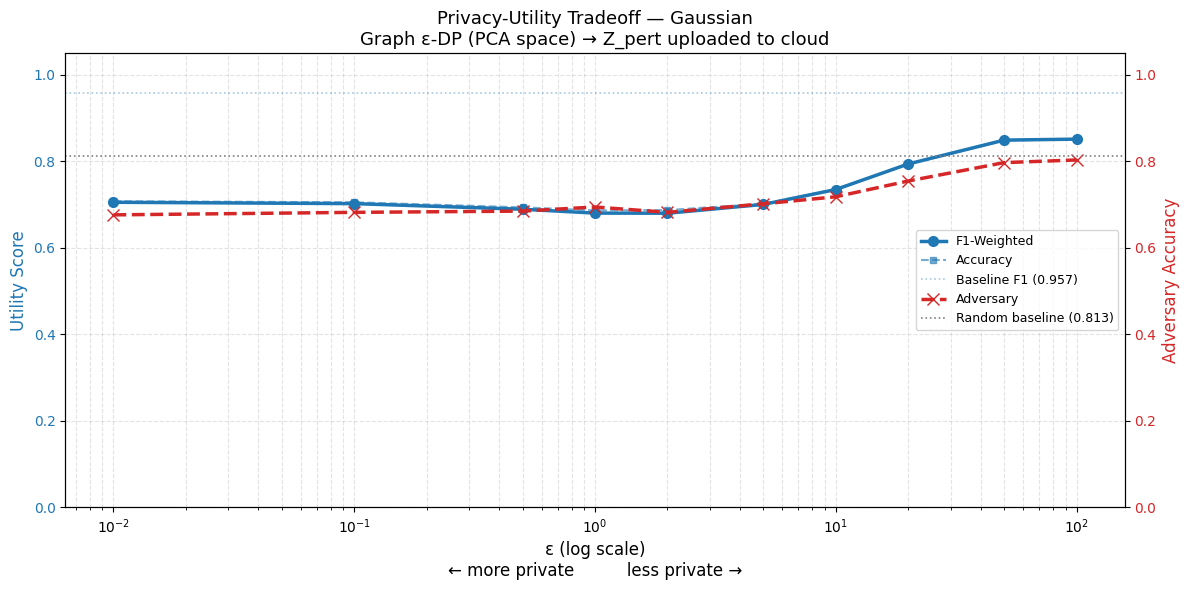


──────────────────────────────────────────────────  edge_flip  ──────────────────────────────────────────────────


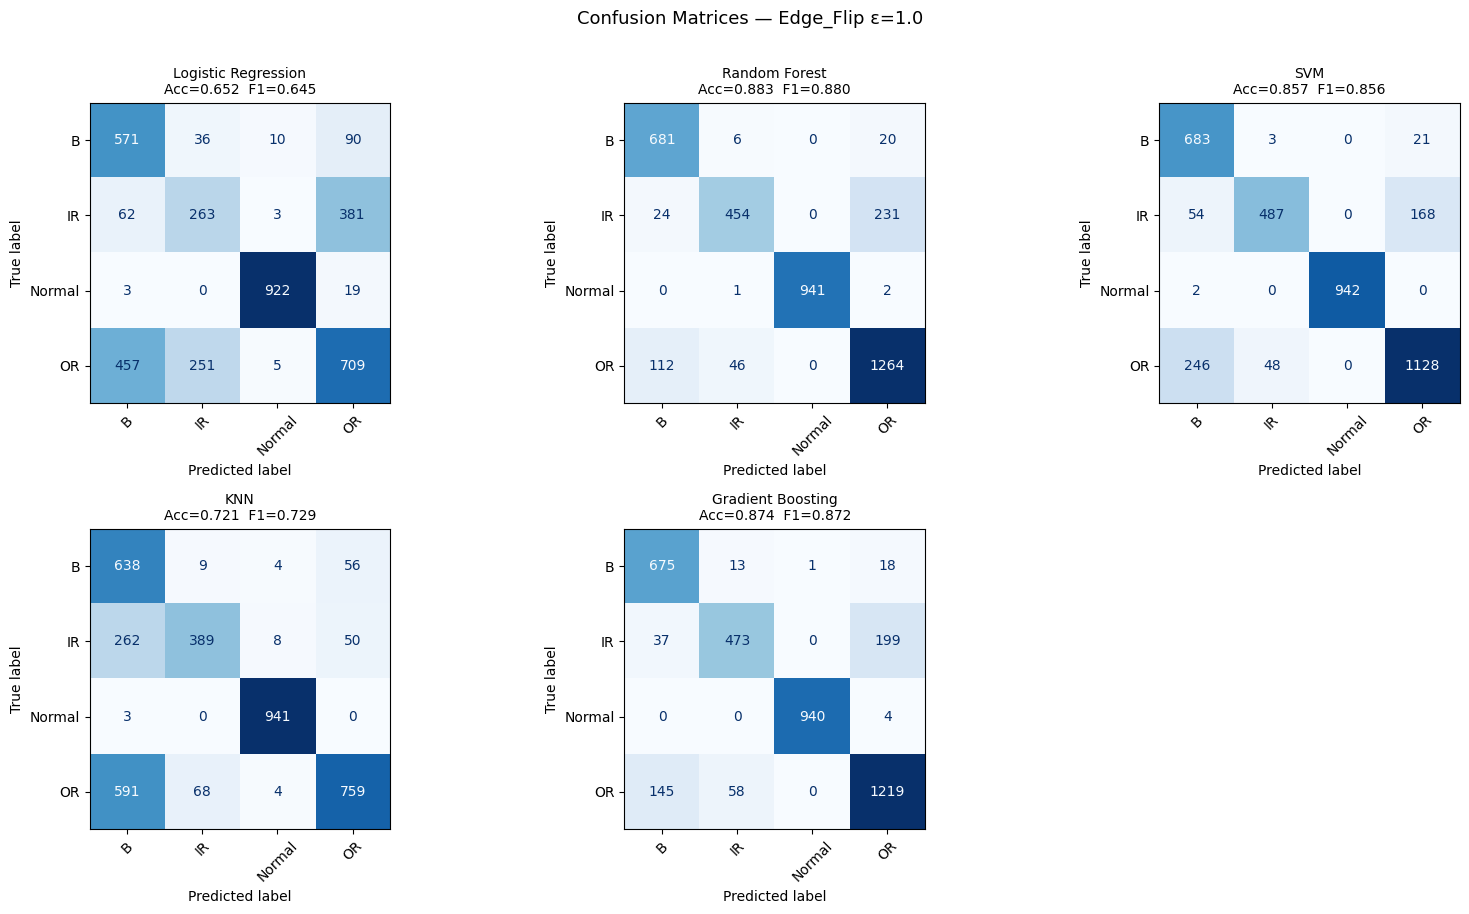

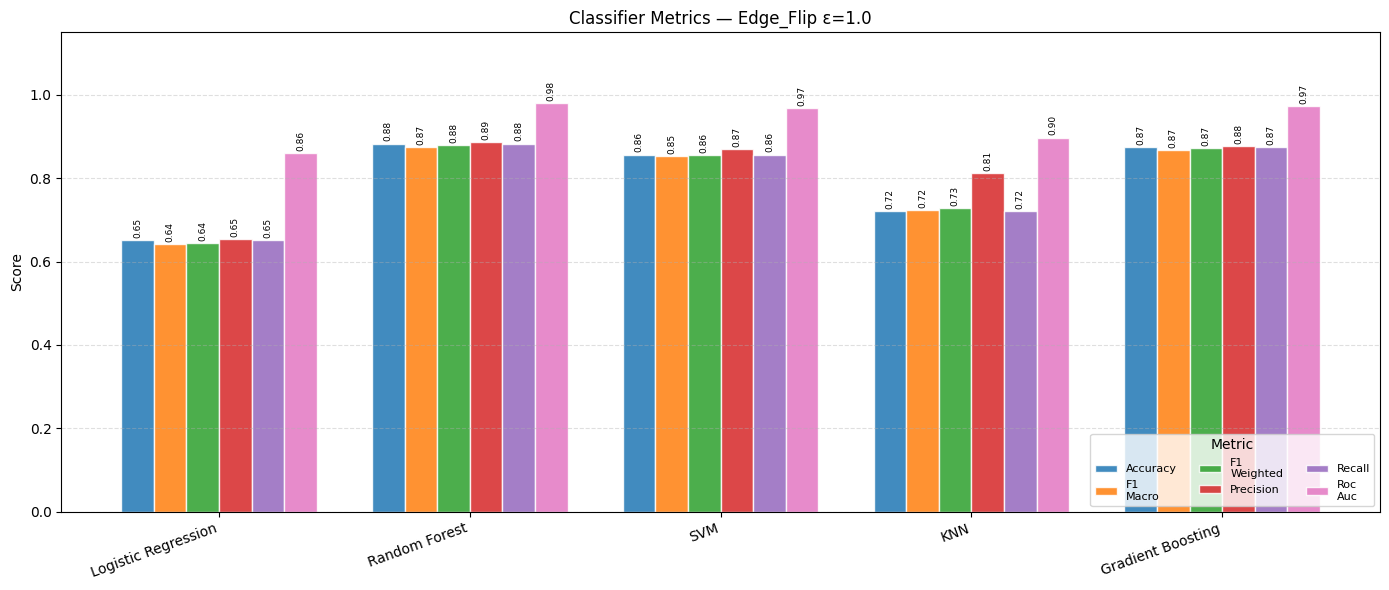

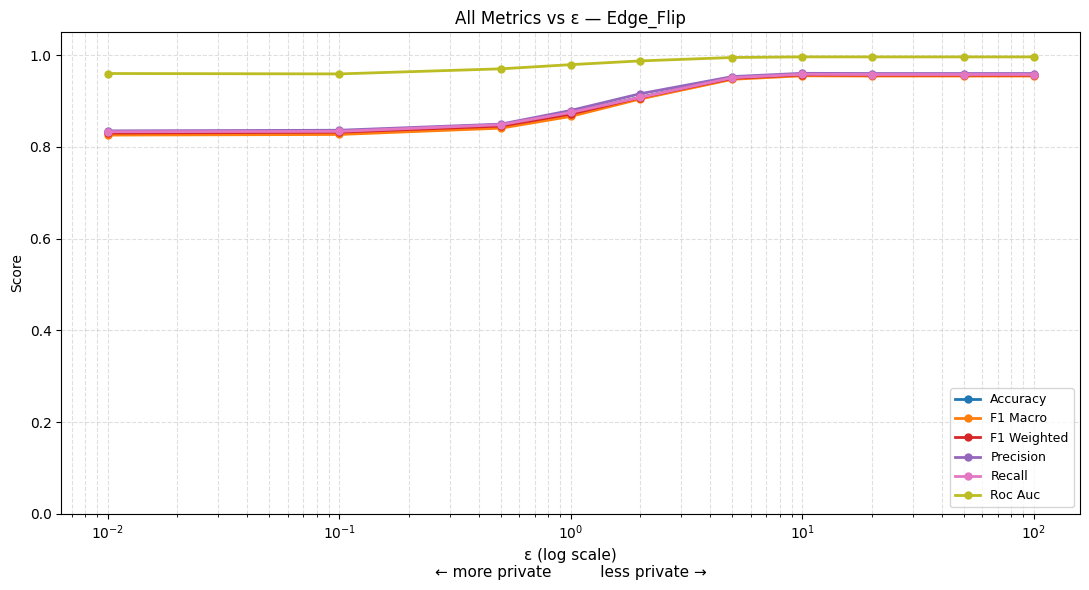

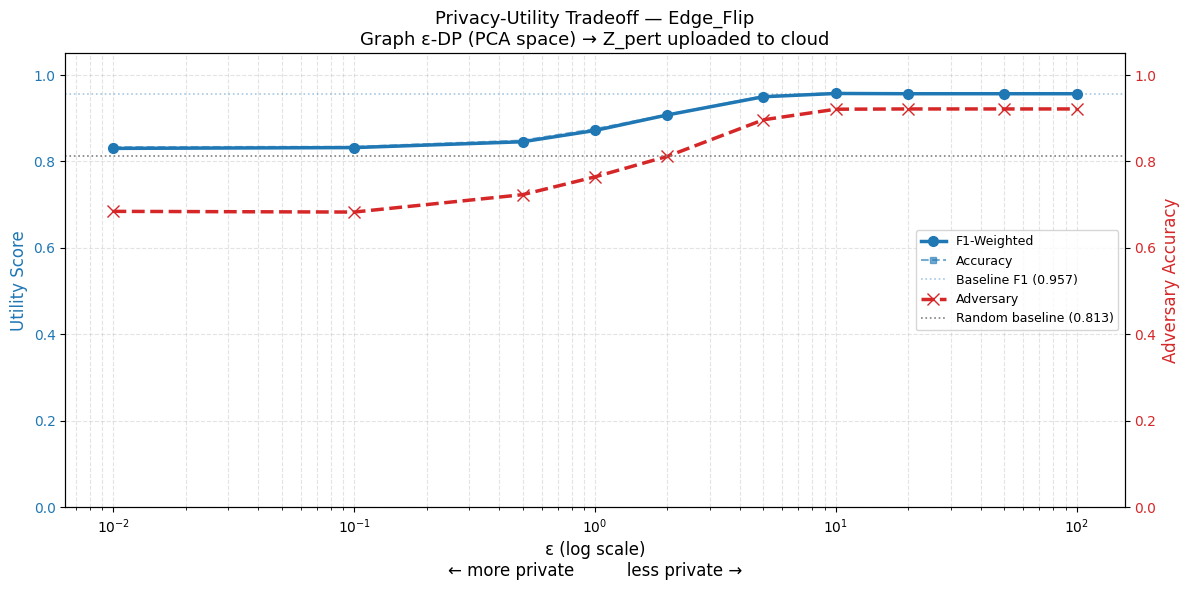

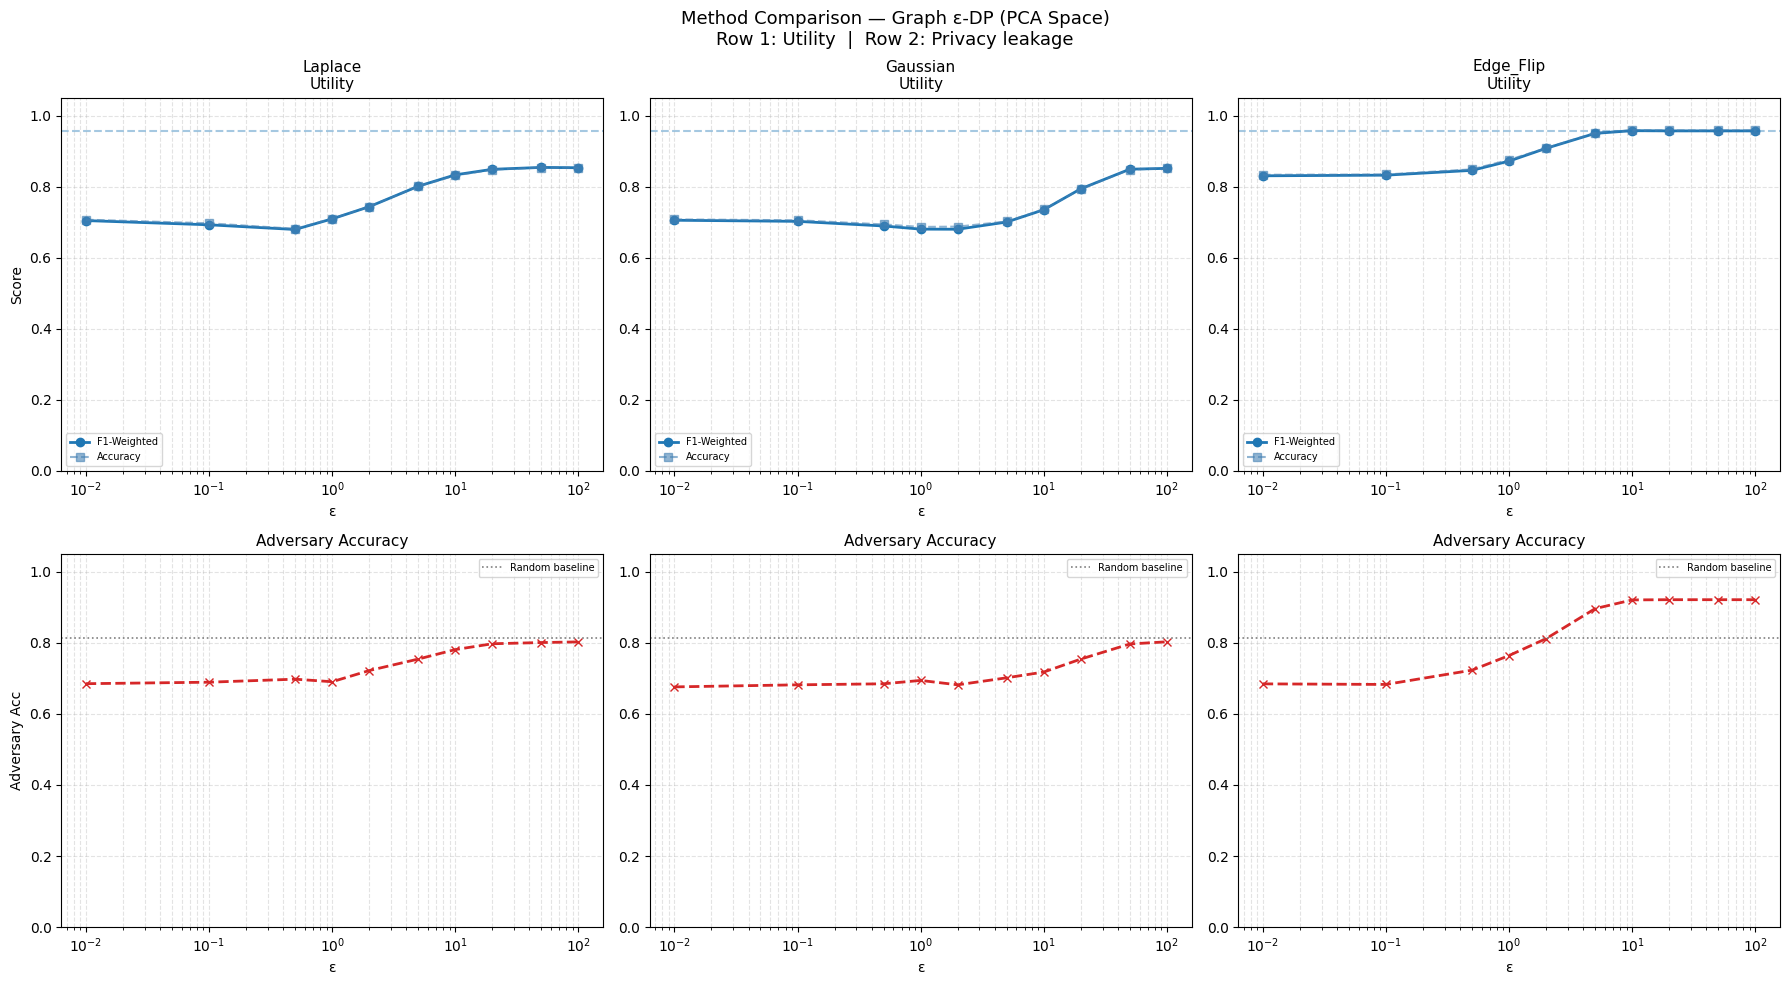

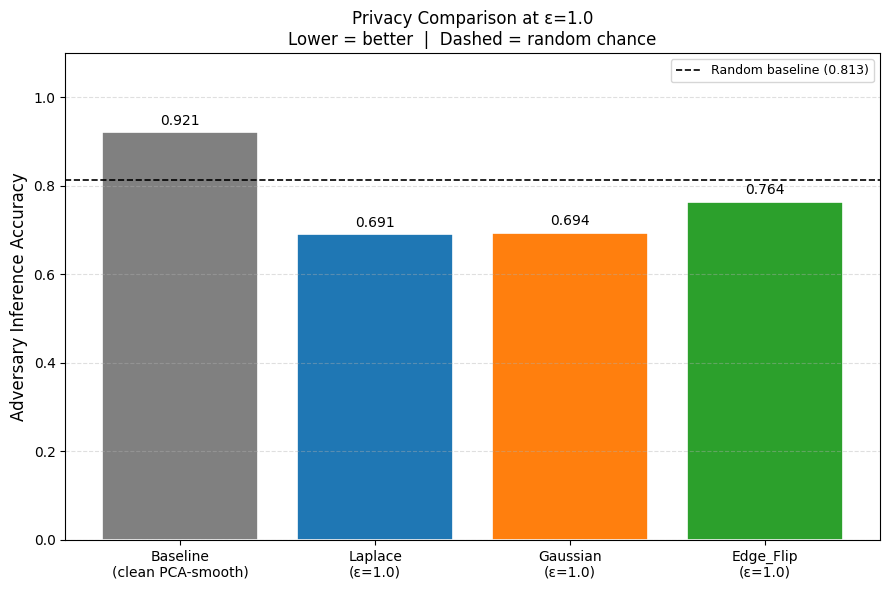


✓ All plots saved.


In [12]:
def plot_confusion_matrices(results, class_names=None, label=""):
    n = len(results); ncols = min(3,n); nrows = int(np.ceil(n/ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 4.5*nrows))
    axes = np.array(axes).flatten()
    for idx, (name, m) in enumerate(results.items()):
        ConfusionMatrixDisplay(m["conf_matrix"], display_labels=class_names).plot(
            ax=axes[idx], colorbar=False, cmap="Blues")
        axes[idx].set_title(f"{name}\nAcc={m['accuracy']:.3f}  F1={m['f1_weighted']:.3f}", fontsize=10)
        axes[idx].tick_params(axis="x", rotation=45)
    for idx in range(len(results), len(axes)): axes[idx].set_visible(False)
    plt.suptitle(f"Confusion Matrices — {label}", fontsize=13, y=1.01)
    plt.tight_layout()
    fname = f"confusion_{label.replace(' ','_').replace('=','')}.png"
    plt.savefig(fname, dpi=200, bbox_inches="tight"); plt.show()


def plot_metrics_bar(results, label="", class_names=None):
    df = results_to_df(results)
    metrics = ["accuracy","f1_macro","f1_weighted","precision","recall","roc_auc"]
    x = np.arange(len(df)); width = 0.13
    colors = plt.cm.tab10(np.linspace(0, 0.6, len(metrics)))
    fig, ax = plt.subplots(figsize=(14, 6))
    for i, (metric, color) in enumerate(zip(metrics, colors)):
        vals = df[metric].values
        bars = ax.bar(x + i*width, vals, width, label=metric.replace("_","\n").title(),
                      color=color, alpha=0.85, edgecolor="white")
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                        f"{val:.2f}", ha="center", va="bottom", fontsize=6.5, rotation=90)
    ax.set_xticks(x + width*(len(metrics)-1)/2)
    ax.set_xticklabels(df.index, rotation=20, ha="right", fontsize=10)
    ax.set_ylabel("Score"); ax.set_ylim(0, 1.15)
    ax.legend(title="Metric", fontsize=8, loc="lower right", ncol=3)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_title(f"Classifier Metrics — {label}", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"metrics_bar_{label.replace(' ','_').replace('=','')}.png",
                dpi=200, bbox_inches="tight"); plt.show()


def plot_metrics_vs_epsilon(records, method=""):
    df = pd.DataFrame(records)
    metrics = ["accuracy","f1_macro","f1_weighted","precision","recall","roc_auc"]
    colors  = plt.cm.tab10(np.linspace(0, 0.8, len(metrics)))
    fig, ax = plt.subplots(figsize=(11, 6))
    for metric, color in zip(metrics, colors):
        if metric in df.columns:
            ax.plot(df["epsilon"], df[metric], marker="o", linewidth=2,
                    markersize=5, label=metric.replace("_"," ").title(), color=color)
    ax.set_xscale("log")
    ax.set_xlabel("ε (log scale)\n← more private          less private →", fontsize=11)
    ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)
    ax.set_title(f"All Metrics vs ε — {method.title()}", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"metrics_vs_epsilon_{method}.png", dpi=200, bbox_inches="tight"); plt.show()


def plot_single_method(df, method):
    sweep = df[df["epsilon"].notna()].copy()
    base  = df[df["label"]=="Baseline"].iloc[0]
    fig, ax1 = plt.subplots(figsize=(12, 6))
    c1 = "tab:blue"
    ax1.set_xlabel("ε (log scale)\n← more private          less private →", fontsize=12)
    ax1.set_ylabel("Utility Score", color=c1, fontsize=12)
    ax1.plot(sweep["epsilon"], sweep["f1_weighted"], color=c1, marker="o",
             linewidth=2.5, markersize=7, label="F1-Weighted")
    ax1.plot(sweep["epsilon"], sweep["accuracy"], color=c1, marker="s",
             linewidth=1.5, markersize=5, linestyle="--", alpha=0.6, label="Accuracy")
    ax1.axhline(base["f1_weighted"], color=c1, linestyle=":", alpha=0.4,
                linewidth=1.2, label=f"Baseline F1 ({base['f1_weighted']:.3f})")
    ax1.set_xscale("log"); ax1.set_ylim(0, 1.05)
    ax1.tick_params(axis="y", labelcolor=c1)
    ax1.grid(True, which="both", linestyle="--", alpha=0.35)
    ax2 = ax1.twinx(); c2 = "tab:red"
    ax2.set_ylabel("Adversary Accuracy", color=c2, fontsize=12)
    ax2.plot(sweep["epsilon"], sweep["adversary_accuracy"], color=c2, marker="x",
             linestyle="--", linewidth=2.5, markersize=8, label="Adversary")
    ax2.axhline(sweep["random_baseline"].iloc[0], color="grey", linestyle=":",
                linewidth=1.2, label=f"Random baseline ({sweep['random_baseline'].iloc[0]:.3f})")
    ax2.set_ylim(0, 1.05); ax2.tick_params(axis="y", labelcolor=c2)
    l1,lb1 = ax1.get_legend_handles_labels(); l2,lb2 = ax2.get_legend_handles_labels()
    ax1.legend(l1+l2, lb1+lb2, loc="center right", fontsize=9)
    plt.title(f"Privacy-Utility Tradeoff — {method.title()}\n"
              f"Graph ε-DP (PCA space) → Z_pert uploaded to cloud", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"sweep_{method}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"sweep_{method}.pdf", bbox_inches="tight"); plt.show()


def plot_method_comparison(sweep_results):
    methods = list(sweep_results.keys())
    fig, axes = plt.subplots(2, len(methods), figsize=(6*len(methods), 10))
    if len(methods)==1: axes = np.array(axes).reshape(2,1)
    for col, method in enumerate(methods):
        df = sweep_results[method]; sweep = df[df["epsilon"].notna()].copy()
        base = df[df["label"]=="Baseline"].iloc[0]
        au = axes[0,col]
        au.plot(sweep["epsilon"], sweep["f1_weighted"], marker="o", color="tab:blue", linewidth=2, label="F1-Weighted")
        au.plot(sweep["epsilon"], sweep["accuracy"], marker="s", color="steelblue", linewidth=1.5, linestyle="--", alpha=0.6, label="Accuracy")
        au.axhline(base["f1_weighted"], color="tab:blue", linestyle="--", alpha=0.4)
        au.set_xscale("log"); au.set_ylim(0, 1.05)
        au.set_title(f"{method.title()}\nUtility", fontsize=11)
        au.set_xlabel("ε"); au.set_ylabel("Score" if col==0 else "")
        au.legend(fontsize=7); au.grid(True, which="both", linestyle="--", alpha=0.35)
        ap = axes[1,col]
        ap.plot(sweep["epsilon"], sweep["adversary_accuracy"], marker="x", color="tab:red", linestyle="--", linewidth=2)
        ap.axhline(sweep["random_baseline"].iloc[0], color="grey", linestyle=":", linewidth=1.2, label="Random baseline")
        ap.set_xscale("log"); ap.set_ylim(0, 1.05)
        ap.set_title("Adversary Accuracy", fontsize=11)
        ap.set_xlabel("ε"); ap.set_ylabel("Adversary Acc" if col==0 else "")
        ap.legend(fontsize=7); ap.grid(True, which="both", linestyle="--", alpha=0.35)
    plt.suptitle("Method Comparison — Graph ε-DP (PCA Space)\n"
                 "Row 1: Utility  |  Row 2: Privacy leakage", fontsize=13)
    plt.tight_layout()
    plt.savefig("method_comparison.png", dpi=300, bbox_inches="tight")
    plt.savefig("method_comparison.pdf", bbox_inches="tight"); plt.show()


def plot_inference_bar(sweep_results, epsilon_highlight=1.0):
    mc = {"laplace":"tab:blue","gaussian":"tab:orange","edge_flip":"tab:green"}
    labels = ["Baseline\n(clean PCA-smooth)"]; adversary = []; colors_l = ["grey"]
    first_df = list(sweep_results.values())[0]
    adversary.append(first_df[first_df["label"]=="Baseline"]["adversary_accuracy"].values[0])
    for method, df in sweep_results.items():
        row = df[df["epsilon"]==epsilon_highlight]
        if len(row):
            labels.append(f"{method.title()}\n(ε={epsilon_highlight})")
            adversary.append(row["adversary_accuracy"].values[0])
            colors_l.append(mc.get(method, "steelblue"))
    fig, ax = plt.subplots(figsize=(9, 6))
    bars = ax.bar(labels, adversary, color=colors_l, edgecolor="white", linewidth=1.2)
    rbl  = float(first_df["random_baseline"].iloc[-1])
    ax.axhline(rbl, color="black", linestyle="--", linewidth=1.2, label=f"Random baseline ({rbl:.3f})")
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.01, f"{h:.3f}", ha="center", va="bottom", fontsize=10)
    ax.set_ylabel("Adversary Inference Accuracy", fontsize=12); ax.set_ylim(0, 1.1)
    ax.set_title(f"Privacy Comparison at ε={epsilon_highlight}\nLower = better  |  Dashed = random chance", fontsize=12)
    ax.legend(fontsize=9); ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig("inference_comparison.png", dpi=300, bbox_inches="tight")
    plt.savefig("inference_comparison.pdf", bbox_inches="tight"); plt.show()


# ── Generate all plots ────────────────────────────────────────────────────
eps_h = CFG["epsilon_highlight"]

for method in CFG["methods"]:
    print(f"\n{'─'*50}  {method}  {'─'*50}")
    Z_all_pert_h, _ = perturb_smooth_features(
        Z_all_smooth, eps_h, method=method,
        delta=CFG["delta"], clip_thresholds=clip_thresholds_pca
    )
    res_h = run_classifiers(Z_all_pert_h[:n_train], Z_all_pert_h[n_train:],
                             y_train, y_test, class_names=CFG["class_names"], verbose=False)
    plot_confusion_matrices(res_h, CFG["class_names"], label=f"{method.title()} ε={eps_h}")
    plot_metrics_bar(res_h, label=f"{method.title()} ε={eps_h}", class_names=CFG["class_names"])
    plot_metrics_vs_epsilon(sweep_records[method], method=method)
    plot_single_method(sweep_results[method], method=method)

plot_method_comparison(sweep_results)
plot_inference_bar(sweep_results, epsilon_highlight=eps_h)
print("\n✓ All plots saved.")